# Домашнее задание 2

## Импорты

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используем: {device}')

Используем: cpu


## Загрузка MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f'Train: {len(train_data)}, Test: {len(test_data)}')

Train: 60000, Test: 10000


## Модель

In [3]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = SimpleNet().to(device)
print(model)

SimpleNet(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


## Обучение

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
writer = SummaryWriter('runs/mnist_simple')

history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
best_acc = 0
best_model_path = 'best_model.pth'

for epoch in range(5):
    model.train()
    train_loss = 0
    train_correct = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
    
    train_acc = 100 * train_correct / len(train_data)
    train_loss = train_loss / len(train_loader)
    
    model.eval()
    test_correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            test_correct += (predicted == labels).sum().item()
    
    test_acc = 100 * test_correct / len(test_data)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    
    writer.add_scalar('Loss/train', train_loss, epoch)
    writer.add_scalar('Accuracy/train', train_acc, epoch)
    writer.add_scalar('Accuracy/test', test_acc, epoch)
    writer.flush()
    
    print(f'Epoch {epoch+1}: Loss={train_loss:.4f}, Train={train_acc:.2f}%, Test={test_acc:.2f}%')
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), best_model_path)

writer.close()
print(f'\nЛучшая точность: {best_acc:.2f}%')

Epoch 1: Loss=0.2053, Train=93.75%, Test=98.49%
Epoch 2: Loss=0.0772, Train=97.75%, Test=98.90%
Epoch 3: Loss=0.0577, Train=98.28%, Test=99.05%
Epoch 4: Loss=0.0464, Train=98.62%, Test=98.89%
Epoch 5: Loss=0.0401, Train=98.78%, Test=99.23%

Лучшая точность: 99.23%


## Метрики

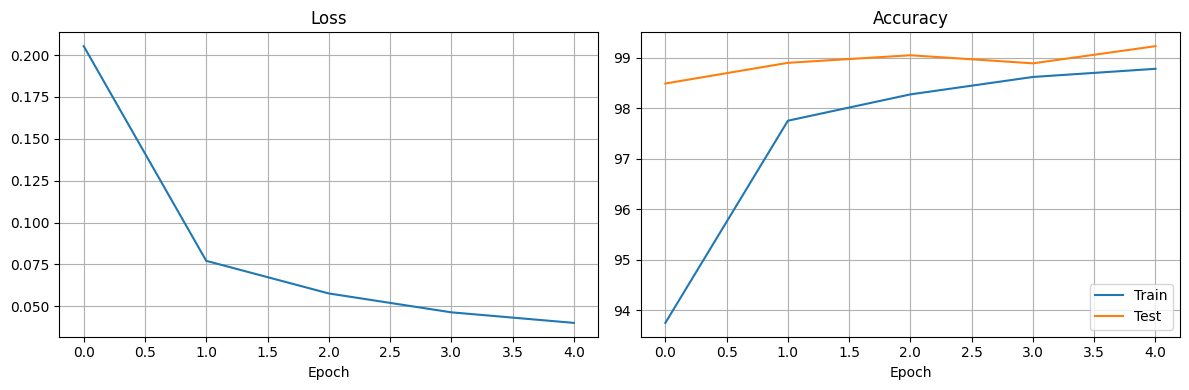

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'])
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['test_acc'], label='Test')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

## Загрузка лучшей модели и предсказания

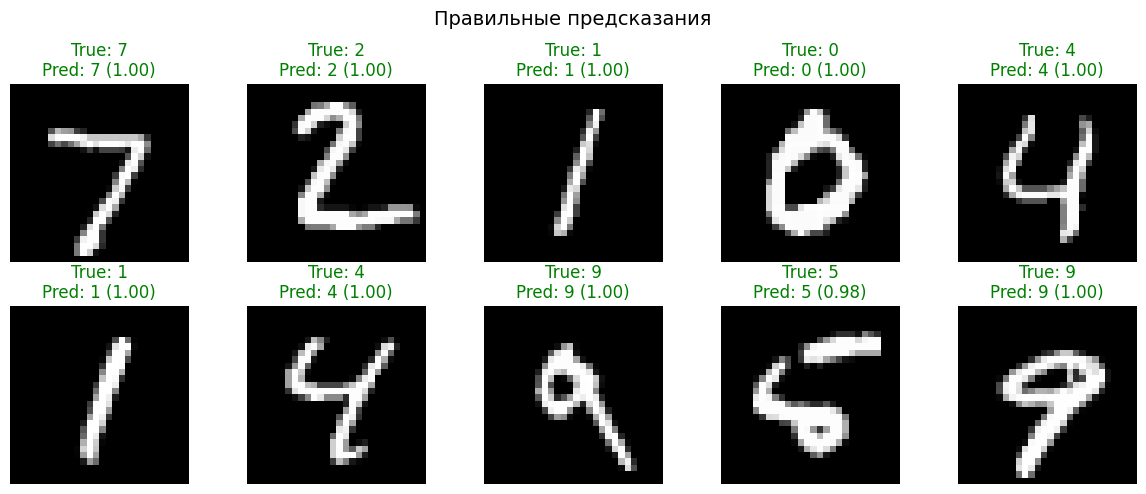

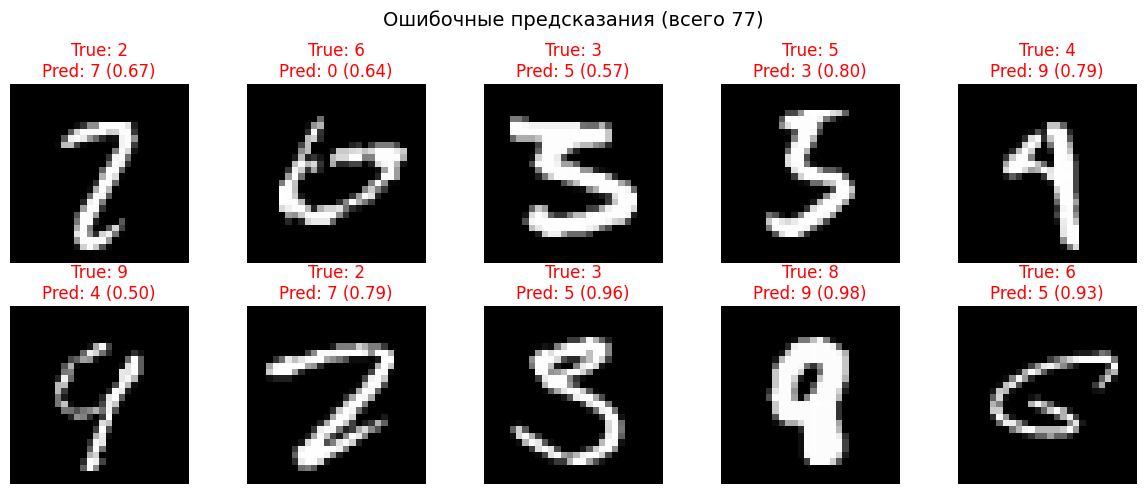

In [8]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

with torch.no_grad():
    all_images = []
    all_labels = []
    all_predicted = []
    all_probs = []
    
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, 1)
        predicted = torch.max(outputs, 1)[1]
        
        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_predicted.append(predicted.cpu())
        all_probs.append(probs.cpu())
    
    all_images = torch.cat(all_images)
    all_labels = torch.cat(all_labels)
    all_predicted = torch.cat(all_predicted)
    all_probs = torch.cat(all_probs)
    
    correct_mask = all_labels == all_predicted
    
    # Правильные предсказания
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    axes = axes.flatten()
    correct_indices = torch.where(correct_mask)[0][:10]
    
    for i, idx in enumerate(correct_indices):
        axes[i].imshow(all_images[idx].squeeze(), cmap='gray')
        true = all_labels[idx].item()
        pred = all_predicted[idx].item()
        conf = all_probs[idx, pred].item()
        axes[i].set_title(f'True: {true}\nPred: {pred} ({conf:.2f})', color='green')
        axes[i].axis('off')
    
    plt.suptitle('Правильные предсказания', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Ошибочные предсказания
    incorrect_indices = torch.where(~correct_mask)[0]
    if len(incorrect_indices) > 0:
        fig, axes = plt.subplots(2, 5, figsize=(12, 5))
        axes = axes.flatten()
        
        for i, idx in enumerate(incorrect_indices[:10]):
            axes[i].imshow(all_images[idx].squeeze(), cmap='gray')
            true = all_labels[idx].item()
            pred = all_predicted[idx].item()
            conf = all_probs[idx, pred].item()
            axes[i].set_title(f'True: {true}\nPred: {pred} ({conf:.2f})', color='red')
            axes[i].axis('off')
        
        plt.suptitle(f'Ошибочные предсказания (всего {(~correct_mask).sum().item()})', fontsize=14)
        plt.tight_layout()
        plt.show()
    else:
        print("Ошибок не найдено!")

## Выводы

Обучение прошло хорошо. На первой эпохе loss был 0.2053, к концу упал до 0.0401. Точность на train выросла с 93.75% до 98.78%, на test - с 98.49% до 99.23%.

Всего ошибок на тесте получилось 77 из 10000. 

Модель учится быстро - уже к третьей эпохе достигает 99% accuracy. На четвёртой эпохе точность немного падает, но на пятой восстанавливается. Судя по кривым, переобучения нет - train и test идут параллельно.

Dropout явно помогает, потому что train и test не расходятся. Если бы его не было, train бы рос намного быстрее, а test отставал.

Архитектура простая, но её достаточно, чтобы выучить паттерны цифр.